<a target="_blank" href="https://colab.research.google.com/github/lukebarousse/Python_Data_Analytics_Course/blob/main/4_Problems/1_24_Pandas Inspection.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [35]:

import pandas as pd
df = pd.read_csv("hf://datasets/lukebarousse/data_jobs/data_jobs.csv")

---

## 🟩 Access Third Row (1.24.1)

In [15]:
df.iloc[3]

,3
job_title_short,Data Engineer
job_title,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...
job_location,"San Antonio, TX"
job_via,via Diversity.com
job_schedule_type,Full-time
job_work_from_home,False
search_location,"Texas, United States"
job_posted_date,2023-07-04 13:01:41
job_no_degree_mention,True
job_health_insurance,False


---

## 🟨 Unique Job Countries (1.24.2)

In [16]:
df.job_country.unique()

array(['United States', 'Mexico', 'Germany', 'Sudan', 'Romania',
       'Denmark', 'Switzerland', 'France', 'Brazil', 'United Kingdom',
       'India', 'Poland', 'Belgium', 'Russia', 'Serbia', 'Singapore',
       'Costa Rica', 'Ireland', 'Italy', 'Malaysia', 'Canada', 'Uruguay',
       'Namibia', 'Estonia', 'Israel', 'Hungary', 'Austria',
       'Philippines', 'Egypt', 'Australia', 'Chile', 'Spain',
       'Netherlands', 'South Africa', 'Colombia', 'Hong Kong', 'Kuwait',
       'Finland', 'Luxembourg', 'China', 'Puerto Rico', 'Sweden',
       'Saudi Arabia', 'Argentina', 'Turkey', 'Panama', 'Nigeria',
       'New Zealand', 'Ukraine', 'Jordan', 'United Arab Emirates',
       'Armenia', 'Pakistan', 'Lesotho', 'Mauritius', 'Portugal',
       'Bahrain', 'Taiwan', "Côte d'Ivoire", 'U.S. Virgin Islands',
       'Réunion', 'Kazakhstan', 'Lithuania', 'Moldova', 'Belarus',
       'Cyprus', 'Bulgaria', 'Honduras', 'Czechia', 'Peru', 'South Korea',
       'Malta', 'Indonesia', 'Tunisia', 'Latvia'

---

## 🟨 Filter by Job Schedule Type and Display (1.24.3)

In [19]:
df.job_schedule_type.unique()

array(['Full-time', 'Contractor and Temp work',
       'Full-time and Internship', 'Temp work', 'Contractor',
       'Full-time and Part-time', 'Full-time and Temp work',
       'Full-time and Contractor', 'Part-time', 'Internship', nan,
       'Part-time and Contractor', 'Temp work and Internship',
       'Full-time, Part-time, and Contractor',
       'Full-time, Part-time, and Internship',
       'Full-time, Contractor, and Temp work',
       'Full-time, Part-time, and Temp work',
       'Full-time, Temp work, and Internship',
       'Full-time, Contractor, and Internship',
       'Part-time and Internship', 'Contractor and Internship',
       'Part-time and Full-time', 'Part-time and Temp work',
       'Full-time and Volunteer', 'Contractor, Temp work, and Internship',
       'Full-time and Per diem', 'Per diem', 'Volunteer',
       'Part-time, Contractor, and Temp work',
       'Full-time, Temp work, and Per diem',
       'Part-time, Temp work, and Internship', 'Contractor and Part

---

## 🟥 Check Missing Values (1.24.4)

In [20]:
df.isna().sum()

,0
job_title_short,0
job_title,1
job_location,1045
job_via,8
job_schedule_type,12667
job_work_from_home,0
search_location,0
job_posted_date,0
job_no_degree_mention,0
job_health_insurance,0


In [21]:
df.job_posted_date[0]

'2023-06-16 13:44:15'

In [36]:
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)

In [37]:
df['job_posted_month']=df['job_posted_date'].dt.month

In [31]:
df.sort_values(by='job_posted_month', inplace=True)

In [32]:
df.drop(labels='salary_hour_avg', axis=1, inplace=True)

In [33]:
df.dropna(subset=['salary_year_avg'], inplace=True)

In [38]:
df.describe()

,job_posted_date,salary_year_avg,salary_hour_avg,job_posted_month
count,785741,22003.000000,10662.000000,785741.000000
mean,2023-06-25 16:02:11.860248576,123286.274072,47.016598,6.305538
min,2023-01-01 00:00:04,15000.000000,8.000000,1.000000
25%,2023-03-20 10:05:48,90000.000000,27.500000,3.000000
50%,2023-06-29 06:11:38,115000.000000,45.980000,6.000000
75%,2023-09-27 01:01:16,150000.000000,61.159996,9.000000
max,2023-12-31 23:59:58,960000.000000,391.000000,12.000000
std,NaN,48312.449482,21.890738,3.525408


---

In [40]:
df.job_title_short.value_counts()

,count
job_title_short,
Data Analyst,196075
Data Engineer,186241
Data Scientist,172286
Business Analyst,49063
Software Engineer,44929
Senior Data Engineer,44563
Senior Data Scientist,36957
Senior Data Analyst,29216
Machine Learning Engineer,14080


In [42]:
df.salary_year_avg.idxmin()

665729

In [43]:
df.salary_year_avg.min()

15000.0

In [44]:
df.iloc[665729]

,665729
job_title_short,Data Engineer
job_title,Data Engineer - Hadoop
job_location,Brazil
job_via,via LinkedIn
job_schedule_type,Full-time
job_work_from_home,False
search_location,Brazil
job_posted_date,2023-12-09 10:05:30
job_no_degree_mention,True
job_health_insurance,False


In [52]:
df1 = df.groupby('job_title_short')['salary_year_avg'].agg(['mean', 'min']).sort_values(ascending=False, by='mean')

<Axes: title={'center': 'Jobs by highest mean salary and min salary'}, xlabel='Job Titles', ylabel='US dollars'>

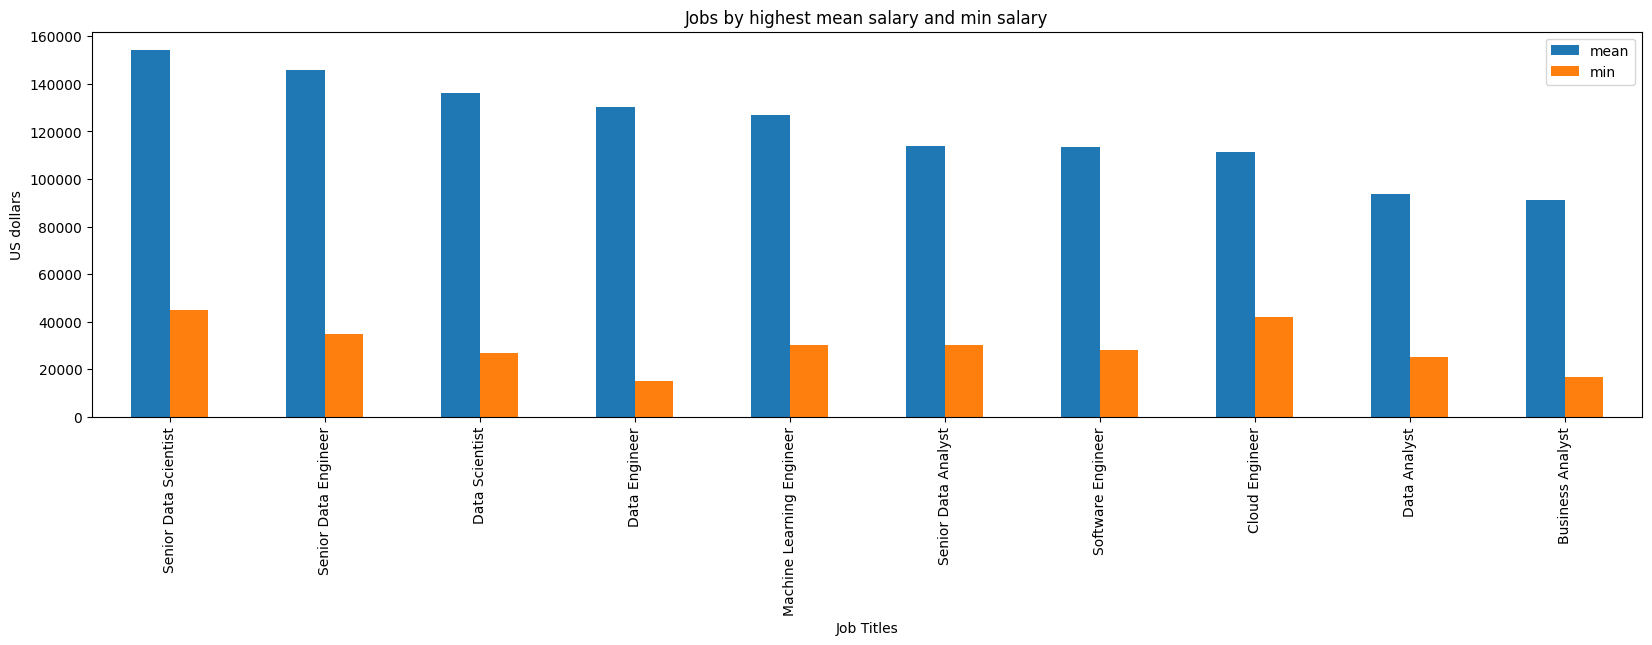

In [60]:
df1.plot(kind='bar', figsize=(20,5), title='Jobs by highest mean salary and min salary', ylabel='US dollars', xlabel='Job Titles')